# Dynamic System Pool Analysis

This notebook compares the **DynamicSystem** variance-driven pool strategy against
baseline Pronghorn orchestration strategies on two representative PyPy serverless
functions: **BFS** and **MST**.

## Key Design Choices
- **Focused benchmarks**: Only BFS and MST are tested (edit `BENCHMARKS` to add more).
- **PyPy-first**: Java/JVM analysis is optional — set `INCLUDE_JAVA = True` to enable it.
- **Modular strategies**: All strategies are defined in a single `STRATEGIES` config dict.
  To benchmark a new strategy, simply add an entry there.
- **Consistent CSV schema**: Uses the same column format as `synthetic_run.py` so
  results from `run.sh` and `run_dynamic_system.sh` can be analysed together.

### CSV Column Format
```
request_number, benchmark, mutability, strategy, rate, client, server, overhead
```

In [73]:
# ── Imports ──────────────────────────────────────────────────────────
import math
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import gmean

In [74]:
# ── Seaborn styling ─────────────────────────────────────────────────
sns.set()
sns.set_context("poster", font_scale=1.25)
sns.set_style("ticks")

## 1 — Configuration

All experiment parameters are defined here.  
To add a new strategy, append an entry to `STRATEGIES`.  
To add a new benchmark, append to `BENCHMARKS`.

In [75]:
# ── Experiment configuration ────────────────────────────────────────

# Benchmarks to analyse (PyPy serverless functions)
BENCHMARKS = ['bfs']

# Set to True to include JVM benchmarks in the analysis
INCLUDE_JAVA = False
JAVA_BENCHMARKS = ['matrix-multiplication', 'word-count', 'simple-hash', 'html-rendering']

# ── Strategy registry (modular) ─────────────────────────────────────
# Each key is a human-readable label; each value is the strategy
# string as it appears in the CSV 'strategy' column.
#
# To benchmark another strategy:
#   1. Add its ENV identifier here.
#   2. Make sure the corresponding CSV data exists in ../data/.
STRATEGIES = {
    'Request Centric':  'request_centric&max_capacity=12',
    'Dynamic System':   'dynamic_system',
    'Cold': 'cold',
    'Fixed':            'fixed&request_to_checkpoint=1',
}

# The baseline strategy that others are compared against
BASELINE_STRATEGY_LABEL = 'Request Centric'

# The primary strategy we want to evaluate
EVAL_STRATEGY_LABEL = 'Dynamic System'

# Eviction rates
EVICTION_RATES = [1]

# Mutability (constant for all runs)
MUTABILITIES = [1]

# CSV column schema (must match synthetic_run*.py output)
DF_COLUMNS = [
    'request_number', 'benchmark', 'mutability',
    'strategy', 'rate', 'client', 'server', 'overhead',
]

# Human-readable display names for benchmarks
# BENCHMARK_TITLES = {
#     'bfs': 'BFS',
#     'mst': 'MST',
#     'matrix-multiplication': 'MatrixMult',
#     'word-count': 'WordCount',
#     'simple-hash': 'Hash',
#     'html-rendering': 'HTML Rendering',
# }
BENCHMARK_TITLES = {
    'bfs': 'BFS',
}

# Reverse lookup: strategy CSV string → label
STRATEGY_LABEL_MAP = {v: k for k, v in STRATEGIES.items()}

print(f"Benchmarks:  {BENCHMARKS}")
print(f"Strategies:  {list(STRATEGIES.keys())}")
print(f"Baseline:    {BASELINE_STRATEGY_LABEL}")
print(f"Evaluating:  {EVAL_STRATEGY_LABEL}")
print(f"Include JVM: {INCLUDE_JAVA}")

Benchmarks:  ['bfs']
Strategies:  ['Request Centric', 'Dynamic System', 'Cold', 'Fixed']
Baseline:    Request Centric
Evaluating:  Dynamic System
Include JVM: False


## 2 — Data Loading

Loads CSVs produced by `run.sh` (baseline) and `run_dynamic_system.sh`.
Both use the same column schema so they can be concatenated.

In [76]:
# ── Load data ───────────────────────────────────────────────────────

def load_csv_safe(path: str) -> pd.DataFrame:
    """Load a CSV if it exists; return an empty DataFrame otherwise."""
    try:
        return pd.read_csv(path, names=DF_COLUMNS)
    except FileNotFoundError:
        print(f"⚠ File not found: {path}  (skipping)")
        return pd.DataFrame(columns=DF_COLUMNS)

# # Baseline data (from run.sh / synthetic_run.py)
# dfs_to_concat = [
#     load_csv_safe('../data/python-evaluation.csv'),
# ]

dfs_to_concat = []
# Dynamic System data (from run_dynamic_system.sh)
dfs_to_concat.append(load_csv_safe('../data/python-basic.csv'))

# Optional: Java data
if INCLUDE_JAVA:
    dfs_to_concat.append(load_csv_safe('../data/java-evaluation.csv'))
    dfs_to_concat.append(load_csv_safe('../data/java-evaluation-dynamic-system.csv'))
    BENCHMARKS = BENCHMARKS + JAVA_BENCHMARKS

df_all = pd.concat(dfs_to_concat, ignore_index=True)

# Filter to only the benchmarks we care about
df_all = df_all[df_all['benchmark'].isin(BENCHMARKS)]

# Filter to only strategies we have registered
known_strategies = set(STRATEGIES.values())
df_all = df_all[df_all['strategy'].isin(known_strategies)]

# Add a human-readable strategy label column
df_all['strategy_label'] = df_all['strategy'].map(STRATEGY_LABEL_MAP)

print(f"\nLoaded {len(df_all)} rows")
print(f"Benchmarks present: {sorted(df_all['benchmark'].unique())}")
print(f"Strategies present: {sorted(df_all['strategy_label'].dropna().unique())}")
print(f"Rates present:      {sorted(df_all['rate'].unique())}")


Loaded 1998 rows
Benchmarks present: ['bfs']
Strategies present: ['Cold', 'Dynamic System', 'Fixed', 'Request Centric']
Rates present:      [np.int64(1)]


## 3 — Convergence Analysis

Find the request number at which each strategy converges to its steady-state
latency (within ±2% of the tail median).

In [77]:
# ── Convergence helper ──────────────────────────────────────────────

def find_convergence_point(
    df: pd.DataFrame,
    benchmark: str,
    strategy_csv: str,
    eviction_rate: int,
    total_requests: int = 500,
    tail_fraction: float = 0.8,
    tolerance: float = 0.02,
    window_size: int = 20,
    skip_initial: int = 100,
) -> int | None:
    """Return the first request index where the sliding-window median
    falls within ±tolerance of the tail median.  Returns None if
    convergence is never reached."""
    subset = df[
        (df['benchmark'] == benchmark)
        & (df['strategy'] == strategy_csv)
        & (df['rate'] == eviction_rate)
    ]
    if subset.empty:
        return None

    latencies = subset['client'].to_numpy()
    tail_start = int(tail_fraction * total_requests)
    target = np.median(latencies[latencies.shape[0] - (total_requests - tail_start):])

    lo = target * (1 - tolerance)
    hi = target * (1 + tolerance)

    for idx in range(skip_initial, len(latencies)):
        window = latencies[idx: idx + window_size]
        if lo <= np.median(window) <= hi:
            return idx
    return None

In [78]:
# ── Compute convergence for every (benchmark, strategy, rate) ──────

convergence_rows = []
for benchmark in BENCHMARKS:
    for label, strat_csv in STRATEGIES.items():
        for rate in EVICTION_RATES:
            conv = find_convergence_point(df_all, benchmark, strat_csv, rate)
            convergence_rows.append({
                'benchmark': benchmark,
                'strategy': label,
                'rate': rate,
                'convergence_request': conv,
            })

df_convergence = pd.DataFrame(convergence_rows)
print(df_convergence.to_string(index=False))

benchmark        strategy  rate  convergence_request
      bfs Request Centric     1                  100
      bfs  Dynamic System     1                  113
      bfs            Cold     1                  100
      bfs           Fixed     1                  100


## 4 — Orchestration Strategy Comparison

Compare median client-side latency across strategies.  The **improvement**
metric is computed as:

```
improvement = (baseline_median - strategy_median) / baseline_median × 100
```

Positive values mean the strategy is faster than the baseline.

In [79]:
# ── Median latency comparison (rate = 1) ────────────────────────────

df_rate1 = df_all[df_all['rate'] == 1].copy()

df_grouped = (
    df_rate1
    .groupby(['benchmark', 'strategy_label'])
    .median(numeric_only=True)['client']
    .reset_index()
)

df_pivot = df_grouped.pivot(
    index='benchmark', columns='strategy_label', values='client'
)

baseline_col = BASELINE_STRATEGY_LABEL
eval_col = EVAL_STRATEGY_LABEL

print("baseline_col", baseline_col)
print("eval_col", eval_col)

# Compute improvement of every strategy vs the baseline
for label in STRATEGIES:
    if label != baseline_col and label in df_pivot.columns:
        df_pivot[f'{label} imp%'] = (
            (df_pivot[baseline_col] - df_pivot[label])
            / df_pivot[baseline_col] * 100
        )

print("Median client latency (rate=1) and improvement vs", baseline_col)
print(df_pivot.round(2).to_string())

baseline_col Request Centric
eval_col Dynamic System
Median client latency (rate=1) and improvement vs Request Centric
strategy_label     Cold  Dynamic System    Fixed  Request Centric  Dynamic System imp%  Cold imp%  Fixed imp%
benchmark                                                                                                    
bfs             43702.5         19731.5  21978.0          18814.0                -4.88    -132.29      -16.82


In [80]:
# ── Categorise benchmarks by improvement ────────────────────────────

THRESHOLD_POS = 5.0   # % improvement to count as "improved"
THRESHOLD_NEG = -5.0  # % improvement to count as "worsened"

imp_col = f'{eval_col} imp%'

if imp_col in df_pivot.columns:
    improved  = df_pivot[df_pivot[imp_col] > THRESHOLD_POS].index.tolist()
    on_par    = df_pivot[(df_pivot[imp_col] >= THRESHOLD_NEG) & (df_pivot[imp_col] <= THRESHOLD_POS)].index.tolist()
    worsened  = df_pivot[df_pivot[imp_col] < THRESHOLD_NEG].index.tolist()

    print(f"Improved  (>{THRESHOLD_POS}%):  {improved}")
    print(f"On par:                {on_par}")
    print(f"Worsened  (<{THRESHOLD_NEG}%): {worsened}")

    positive = df_pivot[df_pivot[imp_col] > THRESHOLD_POS][imp_col]
    if len(positive) > 0:
        print(f"\nGeometric mean of positive improvements: {gmean(positive):.2f}%")
else:
    print(f"Column '{imp_col}' not found — ensure {eval_col} data is loaded.")

Improved  (>5.0%):  []
On par:                ['bfs']
Worsened  (<-5.0%): []


## 5 — Request-Rate Analysis

Analyse how the `Dynamic System` strategy performs across all eviction rates.

In [81]:
# ── Improvement across all rates ────────────────────────────────────

df_grouped_all = (
    df_all
    .groupby(['benchmark', 'strategy_label', 'rate'])
    .median(numeric_only=True)['client']
    .reset_index()
)

df_pivot_all = df_grouped_all.pivot(
    index=['benchmark', 'rate'], columns='strategy_label', values='client'
)

if baseline_col in df_pivot_all.columns and eval_col in df_pivot_all.columns:
    df_pivot_all['improvement'] = (
        (df_pivot_all[baseline_col] - df_pivot_all[eval_col])
        / df_pivot_all[baseline_col] * 100
    )

    print(f"Improvement of {eval_col} vs {baseline_col} by (benchmark, rate):")
    print(df_pivot_all['improvement'].round(2).to_string())
else:
    missing = [c for c in [baseline_col, eval_col] if c not in df_pivot_all.columns]
    print(f"Missing strategy columns: {missing}")

Improvement of Dynamic System vs Request Centric by (benchmark, rate):
benchmark  rate
bfs        1      -4.88


In [82]:
# ── Geometric mean improvement per rate ─────────────────────────────

if 'improvement' in df_pivot_all.columns:
    df_pos = df_pivot_all[df_pivot_all['improvement'] > THRESHOLD_POS].reset_index()

    if not df_pos.empty:
        geo_per_rate = df_pos.groupby('rate')['improvement'].apply(gmean)
        print(f"Geometric mean of positive improvements per rate:\n{geo_per_rate}")
    else:
        print("No benchmarks exceeded the positive improvement threshold.")

No benchmarks exceeded the positive improvement threshold.


In [83]:
# ── Per-rate categorisation ─────────────────────────────────────────

if 'improvement' in df_pivot_all.columns:
    improved_all  = df_pivot_all[df_pivot_all['improvement'] > THRESHOLD_POS].index.tolist()
    on_par_all    = df_pivot_all[(df_pivot_all['improvement'] >= THRESHOLD_NEG) & (df_pivot_all['improvement'] <= THRESHOLD_POS)].index.tolist()
    worsened_all  = df_pivot_all[df_pivot_all['improvement'] < THRESHOLD_NEG].index.tolist()

    print(f"Improved:  {improved_all}")
    print(f"On par:    {on_par_all}")
    print(f"Worsened:  {worsened_all}")

    overall_positive = df_pivot_all[df_pivot_all['improvement'] > THRESHOLD_POS]['improvement']
    if len(overall_positive) > 0:
        print(f"\nOverall geometric mean of positive improvements: {gmean(overall_positive):.2f}%")

Improved:  []
On par:    [('bfs', 1)]
Worsened:  []


## 6 — Visualisation

CDF plots of client-side latency for each benchmark, comparing all
registered strategies.

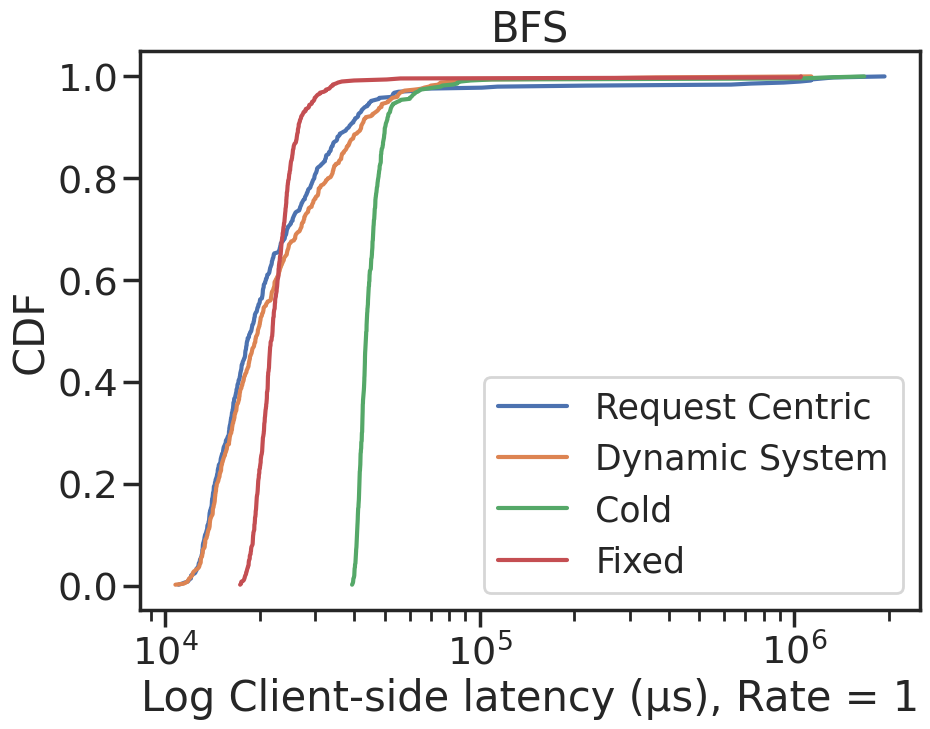

Saved: cdf_dynamic_system.png


In [84]:
# ── CDF plots per benchmark (rate = 1) ──────────────────────────────

fig, axes = plt.subplots(1, len(BENCHMARKS), figsize=(10 * len(BENCHMARKS), 8), squeeze=False)

for col_idx, benchmark in enumerate(BENCHMARKS):
    ax = axes[0, col_idx]
    bm_df = df_rate1[df_rate1['benchmark'] == benchmark]

    for label in STRATEGIES:
        strat_df = bm_df[bm_df['strategy_label'] == label]
        if strat_df.empty:
            continue
        sorted_vals = np.sort(strat_df['client'].values)
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, label=label)

    title = BENCHMARK_TITLES.get(benchmark, benchmark)
    ax.set_title(title)
    ax.set_xlabel('Log Client-side latency (µs), Rate = 1')
    ax.set_ylabel('CDF')
    ax.set_xscale('log')
    ax.legend(fontsize='small')

plt.tight_layout()
plt.savefig('cdf_dynamic_system.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cdf_dynamic_system.png")